# IMDb Movies – Dataset Exploration (EDA)

Ce notebook sert à **valider** le dataset IMDb (parquet) avant d'entraîner un modèle :
- taille du dataset, colonnes, types
- valeurs manquantes
- doublons
- outliers (votes, années, durée)
- distributions (votes en log, rating, années)

> Chemin par défaut : `data/processed/movie_imdb.parquet`


In [23]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.home() / "projets" / "movie-recommender"
sys.path.insert(0, str(PROJECT_ROOT))

import config as cfg
df = pd.read_parquet(PROJECT_ROOT / cfg.DATA_PATH)
df.head()

,tconst,primaryTitle,originalTitle,startYear,runtimeMinutes,genres,genre_tokens,actors,directors,writers,people,averageRating,numVotes,content
0,tt0000009,Miss Jerry,Miss Jerry,1894,45,Romance,g:Romance,Blanche_Bayliss William_Courtenay Chauncey_Depew,Alexander_Black,Alexander_Black,Alexander_Black Blanche_Bayliss William_Courte...,5.2,232,Miss Jerry Romance Alexander_Black Blanche_Bay...
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906,70,Action Adventure Biography,g:Action g:Adventure g:Biography gpair:Action|...,Elizabeth_Tait John_Tait Nicholas_Brierley,Charles_Tait,Charles_Tait,Charles_Tait Elizabeth_Tait John_Tait Nicholas...,6.0,1046,The Story of the Kelly Gang Action Adventure B...
2,tt0001892,Den sorte drøm,Den sorte drøm,1911,53,Drama,g:Drama,Asta_Nielsen Valdemar_Psilander Gunnar_Helseng...,Urban_Gad,Urban_Gad Gebhard_Schätzler-Perasini,Urban_Gad Asta_Nielsen Valdemar_Psilander Gunn...,5.9,292,Den sorte drøm Drama Urban_Gad Asta_Nielsen Va...
3,tt0002101,Cleopatra,Cleopatra,1912,100,Drama History,g:Drama g:History gpair:Drama|History,Helen_Gardner Pearl_Sindelar Miss_Fielding,Charles_L._Gaskill,Victorien_Sardou,Charles_L._Gaskill Helen_Gardner Pearl_Sindela...,5.1,663,Cleopatra Drama History Charles_L._Gaskill Hel...
4,tt0002130,Dante's Inferno,L'inferno,1911,71,Adventure Drama Fantasy,g:Adventure g:Drama g:Fantasy gpair:Adventure|...,Salvatore_Papa Arturo_Pirovano Giuseppe_de_Lig...,Francesco_Bertolini,Dante_Alighieri,Francesco_Bertolini Salvatore_Papa Arturo_Piro...,7.1,4027,Dante's Inferno Adventure Drama Fantasy France...


In [24]:
# Aperçu global
print("Shape:", df.shape)
display(df.sample(5, random_state=42))

Shape: (99068, 14)


,tconst,primaryTitle,originalTitle,startYear,runtimeMinutes,genres,genre_tokens,actors,directors,writers,people,averageRating,numVotes,content
57973,tt13778486,Succubus,Succubus,2024,103,Drama Horror Thriller,g:Drama g:Horror g:Thriller gpair:Drama|Horror...,Brendan_Bradley Olivia_Grace_Applegate Rosanna...,R.J._Daniel_Hanna,R.J._Daniel_Hanna,R.J._Daniel_Hanna Brendan_Bradley Olivia_Grace...,4.7,2004,Succubus Drama Horror Thriller R.J._Daniel_Han...
40250,tt0347332,Khakee,Khakee,2004,174,Action Crime Drama,g:Action g:Crime g:Drama gpair:Action|Crime gp...,Amitabh_Bachchan Akshay_Kumar Ajay_Devgn,Rajkumar_Santoshi,Ranjit_Kapoor Amit_Pachori,Rajkumar_Santoshi Amitabh_Bachchan Akshay_Kuma...,7.4,17380,Khakee Action Crime Drama Rajkumar_Santoshi Am...
50843,tt10730376,The Penthouse,The Penthouse,2021,88,Crime Mystery Thriller,g:Crime g:Mystery g:Thriller gpair:Crime|Myste...,David_Schifter Vanessa_Ore Michael_Paré,Massimiliano_Cerchi,David_Schifter,Massimiliano_Cerchi David_Schifter Vanessa_Ore...,3.1,479,The Penthouse Crime Mystery Thriller Massimili...
44232,tt0450099,A Time to Love,Qing ren jie,2005,113,Drama Romance,g:Drama g:Romance gpair:Drama|Romance,Wei_Zhao Yi_Lu Minjie_Cui,Jianqi_Huo,Wu_Si Renjie_Zhang,Jianqi_Huo Wei_Zhao Yi_Lu Minjie_Cui Wu_Si Ren...,6.4,401,A Time to Love Drama Romance Jianqi_Huo Wei_Zh...
91086,tt6189344,Friends by Chance,Tutto quello che vuoi,2017,106,Comedy Drama,g:Comedy g:Drama gpair:Comedy|Drama,Andrea_Carpenzano Giuliano_Montaldo Arturo_Bruni,Francesco_Bruni,Francesco_Bruni,Francesco_Bruni Andrea_Carpenzano Giuliano_Mon...,7.0,1606,Friends by Chance Comedy Drama Francesco_Bruni...


In [25]:
# Colonnes & types
display(pd.DataFrame({"dtype": df.dtypes.astype(str)}).T)
df.dtypes

,tconst,primaryTitle,originalTitle,startYear,runtimeMinutes,genres,genre_tokens,actors,directors,writers,people,averageRating,numVotes,content
dtype,str,str,str,Int64,Int64,str,str,str,str,str,str,float32,Int64,string


tconst                str
primaryTitle          str
originalTitle         str
startYear           Int64
runtimeMinutes      Int64
genres                str
genre_tokens          str
actors                str
directors             str
writers               str
people                str
averageRating     float32
numVotes            Int64
content            string
dtype: object

In [26]:
# Statistiques rapides pour les colonnes numériques
num_cols = df.select_dtypes(include=["number", "Int64", "float", "int"]).columns
display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
startYear,99068.0,1998.795302,24.541818,1894.0,1986.0,2008.0,2017.0,2026.0
runtimeMinutes,99068.0,101.415674,22.044601,26.0,88.0,97.0,110.0,360.0
averageRating,99068.0,5.897254,1.252634,1.0,5.2,6.1,6.8,9.9
numVotes,99068.0,12383.072536,68730.754656,200.0,379.0,853.0,2947.0,3150021.0


In [27]:
# Taux de valeurs manquantes
missing = df.isna().mean().sort_values(ascending=False)
display(missing.to_frame("missing_rate").head(30))

,missing_rate
tconst,0.0
primaryTitle,0.0
originalTitle,0.0
startYear,0.0
runtimeMinutes,0.0
genres,0.0
genre_tokens,0.0
actors,0.0
directors,0.0
writers,0.0


In [28]:
# Doublons sur tconst (doit idéalement être 0)
dup_tconst = df["tconst"].duplicated().sum() if "tconst" in df.columns else None
print("Duplicated tconst:", dup_tconst)

# Doublons sur (primaryTitle, startYear)
key_cols = [c for c in ["primaryTitle", "startYear"] if c in df.columns]
dup_title_year = df.duplicated(key_cols).sum() if len(key_cols) == 2 else None
print("Duplicated (primaryTitle, startYear):", dup_title_year)

Duplicated tconst: 0
Duplicated (primaryTitle, startYear): 309


In [29]:
# Inspecter les doublons (primaryTitle, startYear) si besoin
if {"primaryTitle","startYear"}.issubset(df.columns):
    dups = df[df.duplicated(["primaryTitle","startYear"], keep=False)]\
            .sort_values(["primaryTitle","startYear"])
    print("Nb lignes concernées:", len(dups))
    display(dups.head(50))
else:
    print("Colonnes primaryTitle/startYear manquantes.")

Nb lignes concernées: 609


,tconst,primaryTitle,originalTitle,startYear,runtimeMinutes,genres,genre_tokens,actors,directors,writers,people,averageRating,numVotes,content
61956,tt1554091,A Better Life,A Better Life,2011,98,Drama Romance,g:Drama g:Romance gpair:Drama|Romance,Demián_Bichir José_Julián Eddie_'Piolin'_Sotelo,Chris_Weitz,Eric_Eason Roger_L._Simon,Chris_Weitz Demián_Bichir José_Julián Eddie_'P...,7.2,17033,A Better Life Drama Romance Chris_Weitz Demián...
67992,tt2027265,A Better Life,Une vie meilleure,2011,110,Drama,g:Drama,Guillaume_Canet Leïla_Bekhti Slimane_Khettabi,Cédric_Kahn,Catherine_Paillé Cédric_Kahn,Cédric_Kahn Guillaume_Canet Leïla_Bekhti Slima...,6.6,1862,A Better Life Drama Cédric_Kahn Guillaume_Cane...
85365,tt4387314,A Christmas Carol,A Christmas Carol,2018,75,Fantasy,g:Fantasy,Bonnie_Wright Rebecca_Hanssen Stuart_Brennan,David_Izatt,Stuart_Brennan Charles_Dickens,David_Izatt Bonnie_Wright Rebecca_Hanssen Stua...,4.3,464,A Christmas Carol Fantasy David_Izatt Bonnie_W...
95984,tt8232648,A Christmas Carol,A Christmas Carol,2018,81,Drama,g:Drama,Simon_Callow,Tom_Cairns,Tom_Cairns Simon_Callow,Tom_Cairns Simon_Callow Tom_Cairns Simon_Callow,7.5,208,A Christmas Carol Drama Tom_Cairns Simon_Callo...
84406,tt4073868,A Decent Man,Nichts passiert,2015,94,Crime Drama,g:Crime g:Drama gpair:Crime|Drama,Devid_Striesow Maren_Eggert Annina_Walt,Micha_Lewinsky,Micha_Lewinsky,Micha_Lewinsky Devid_Striesow Maren_Eggert Ann...,6.6,437,A Decent Man Crime Drama Micha_Lewinsky Devid_...
84471,tt4084060,A Decent Man,Je ne suis pas un salaud,2015,111,Drama,g:Drama,Nicolas_Duvauchelle Mélanie_Thierry Driss_Ramdi,Emmanuel_Finkiel,Emmanuel_Finkiel Julie_Peyr,Emmanuel_Finkiel Nicolas_Duvauchelle Mélanie_T...,6.5,610,A Decent Man Drama Emmanuel_Finkiel Nicolas_Du...
15251,tt0069987,A Doll's House,A Doll's House,1973,105,Drama,g:Drama,Claire_Bloom Anthony_Hopkins Ralph_Richardson,Patrick_Garland,Henrik_Ibsen Christopher_Hampton,Patrick_Garland Claire_Bloom Anthony_Hopkins R...,6.4,1484,A Doll's House Drama Patrick_Garland Claire_Bl...
15252,tt0069988,A Doll's House,A Doll's House,1973,106,Drama,g:Drama,Jane_Fonda Edward_Fox Trevor_Howard,Joseph_Losey,Henrik_Ibsen David_Mercer,Joseph_Losey Jane_Fonda Edward_Fox Trevor_Howa...,6.0,871,A Doll's House Drama Joseph_Losey Jane_Fonda E...
81174,tt3442634,Absolution,Henkesi edestä,2015,92,Drama Thriller,g:Drama g:Thriller gpair:Drama|Thriller,Laura_Birn Eero_Aho Mari_Rantasila,Petri_Kotwica,Petri_Kotwica Johanna_Hartikainen,Petri_Kotwica Laura_Birn Eero_Aho Mari_Rantasi...,6.2,554,Absolution Drama Thriller Petri_Kotwica Laura_...
81600,tt3503840,Absolution,Absolution,2015,96,Action Crime Thriller,g:Action g:Crime g:Thriller gpair:Action|Crime...,Steven_Seagal Byron_Mann Howard_Dell,Keoni_Waxman,Richard_Beattie Keoni_Waxman,Keoni_Waxman Steven_Seagal Byron_Mann Howard_D...,4.4,4237,Absolution Action Crime Thriller Keoni_Waxman ...


In [30]:
# Outliers: années
if "startYear" in df.columns:
    display(df["startYear"].describe())
    display(df[df["startYear"].notna()].sort_values("startYear").head(20)[["primaryTitle","startYear","numVotes","averageRating"]]
            if {"primaryTitle","numVotes","averageRating"}.issubset(df.columns) else df.sort_values("startYear").head(20))
    display(df[df["startYear"].notna()].sort_values("startYear", ascending=False).head(20)[["primaryTitle","startYear","numVotes","averageRating"]]
            if {"primaryTitle","numVotes","averageRating"}.issubset(df.columns) else df.sort_values("startYear", ascending=False).head(20))
else:
    print("startYear absent.")

count        99068.0
mean     1998.795302
std        24.541818
min           1894.0
25%           1986.0
50%           2008.0
75%           2017.0
max           2026.0
Name: startYear, dtype: Float64

,primaryTitle,startYear,numVotes,averageRating
0,Miss Jerry,1894,232,5.2
1,The Story of the Kelly Gang,1906,1046,6.0
36822,Karadjordje,1911,274,6.0
33593,Defense of Sevastopol,1911,294,5.8
2,Den sorte drøm,1911,292,5.9
4,Dante's Inferno,1911,4027,7.1
33697,Pinocchio,1911,264,5.8
39352,The Mystery of the Rocks of Kador,1912,471,6.5
5,From the Manger to the Cross,1912,700,5.9
8,The Independence of Romania,1912,284,6.3


,primaryTitle,startYear,numVotes,averageRating
81771,Baby Girl,2026,1036,6.8
83981,Kaakaa,2026,336,9.0
83982,Sach Ki Kkhoj,2026,506,9.6
72312,The Raja Saab,2026,9139,3.8
83983,Hok Kolorob,2026,224,8.3
81947,Bhanupriya Bhooter Hotel,2026,595,8.7
74767,Nilakanta,2026,2028,9.6
83896,Psych Siddhartha,2026,1036,9.4
79053,Cheekati Lo,2026,4963,6.0
82488,Chatha Pacha: The Ring of Rowdies,2026,1508,7.2


In [31]:
# Outliers: votes & ratings
cols = [c for c in ["primaryTitle","startYear","averageRating","numVotes"] if c in df.columns]
if "numVotes" in df.columns:
    display(df.sort_values("numVotes").head(20)[cols])
    display(df.sort_values("numVotes", ascending=False).head(20)[cols])
else:
    print("numVotes absent.")

,primaryTitle,startYear,averageRating,numVotes
38029,Together,1956,6.8,200
37383,Indrajaalam,1990,6.3,200
72603,Purple Don't Cry,2023,8.4,200
91766,Top Funny Comedian: The Movie,2017,2.5,200
15272,Heroes in Hell,1974,4.2,200
94572,Rivière,2023,6.2,200
25864,Aasoo Bane Angaarey,1993,3.7,200
34947,Jubaku: Spellbound,1999,6.6,200
66861,College Musical,2014,5.8,200
31880,The Kid,1997,5.9,200


,primaryTitle,startYear,averageRating,numVotes
27175,The Shawshank Redemption,1994,9.3,3150021
45014,The Dark Knight,2008,9.1,3125518
57932,Inception,2010,8.8,2779556
30908,Fight Club,1999,8.8,2565915
47052,Interstellar,2014,8.7,2469178
26813,Forrest Gump,1994,8.8,2464726
27112,Pulp Fiction,1994,8.8,2407450
30687,The Matrix,1999,8.7,2222591
14793,The Godfather,1972,9.2,2198185
29804,The Lord of the Rings: The Fellowship of the Ring,2001,8.9,2179270


In [32]:
# Vérifier les bornes de rating (0..10)
if "averageRating" in df.columns:
    bad = df[(df["averageRating"].notna()) & ((df["averageRating"] < 0) | (df["averageRating"] > 10))]
    print("Ratings hors bornes:", len(bad))
    display(bad.head(50))
else:
    print("averageRating absent.")

Ratings hors bornes: 0


,tconst,primaryTitle,originalTitle,startYear,runtimeMinutes,genres,genre_tokens,actors,directors,writers,people,averageRating,numVotes,content


In [33]:
# Longueur du champ 'people'
people_len = df["people"].fillna("").astype(str).str.split().str.len()
display(people_len.describe())
display(df.assign(people_count=people_len).sort_values("people_count").head(20)[
    [c for c in ["primaryTitle","startYear","people_count","people","numVotes"] if c in df.columns]])

count    99068.000000
mean         5.550329
std          0.615217
min          2.000000
25%          5.000000
50%          6.000000
75%          6.000000
max          6.000000
Name: people, dtype: float64

,primaryTitle,startYear,people,numVotes
56458,Savage X Fenty Show Vol. 2,2020,Alex_Rudzinski Bad_Bunny,763
56821,Lady Boss: The Jackie Collins Story,2021,Laura_Fairrie Tita_Cahn,533
92143,The Allins,2017,Sami_Saif Spanky_Payne,497
92262,Dream Boat,2017,Tristan_Ferland_Milewski Martin_Darling,1790
39612,I Am Trying to Break Your Heart,2002,Sam_Jones Bill_Bentley,2278
76178,Tom Cruise: The Last Movie Star,2023,Tom_O'Dell Thomas_Arnold,346
46680,Saint of 9/11,2006,Glenn_Holsten Ian_McKellen,244
98254,5B,2018,Paul_Haggis Sasha_Cuttler,361
76549,Out-Takes from the Life of a Happy Man,2012,Jonas_Mekas Jonas_Mekas,259
76516,Monster Inside: America's Most Extreme Haunted...,2023,Andrew_Renzi Justin_Yerace,1780


In [34]:
# Genres: valeurs fréquentes
if "genres" in df.columns:
    # genres peut être "Action Adventure" ou "Action,Adventure" selon ton pipeline
    g = df["genres"].fillna("").astype(str)
    g = g.str.replace(",", " ")
    tokens = g.str.split()
    flat = tokens.explode()
    top = flat[flat != ""].value_counts().head(30)
    display(top.to_frame("count"))
else:
    print("genres absent.")

,count
genres,
Drama,55404
Comedy,33063
Romance,16058
Action,15265
Thriller,14054
Crime,13917
Horror,12420
Adventure,8881
Mystery,7068


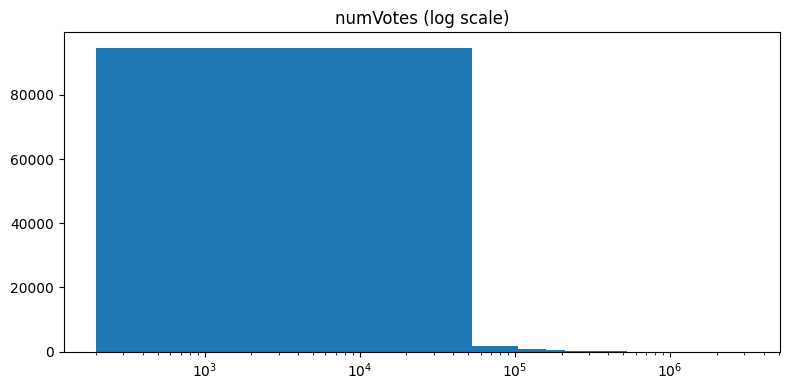

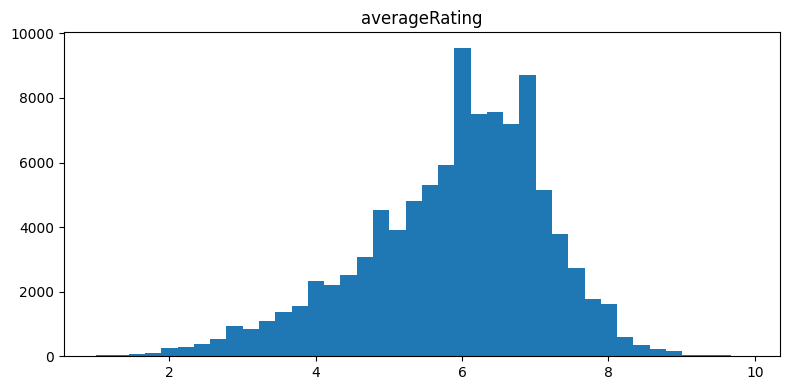

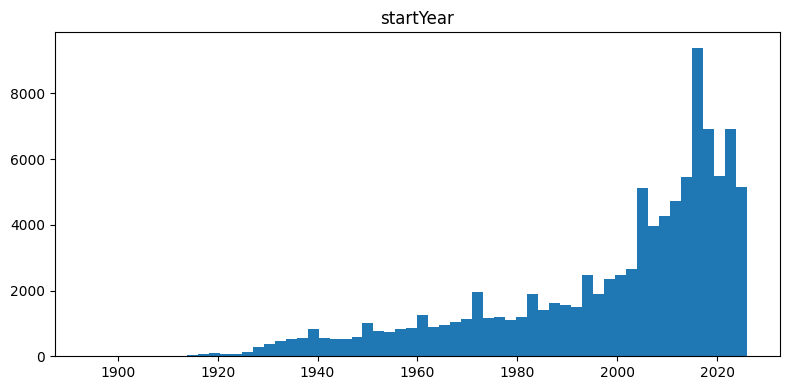

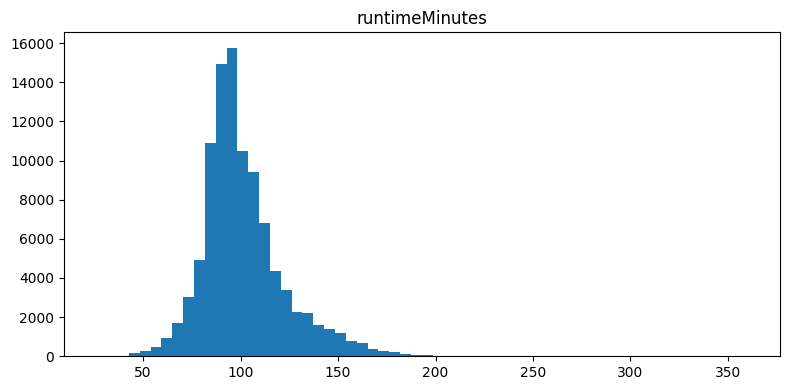

In [35]:
# Plots: distributions (votes en log, rating, années, runtime)
import matplotlib.pyplot as plt

def hist(series, bins=50, logx=False, title=None):
    s = series.dropna()
    plt.figure(figsize=(8,4))
    plt.hist(s, bins=bins)
    if logx:
        plt.xscale("log")
    plt.title(title or series.name)
    plt.tight_layout()
    plt.show()

if "numVotes" in df.columns:
    hist(df["numVotes"], bins=60, logx=True, title="numVotes (log scale)")
if "averageRating" in df.columns:
    hist(df["averageRating"], bins=40, logx=False, title="averageRating")
if "startYear" in df.columns:
    hist(df["startYear"], bins=60, logx=False, title="startYear")
if "runtimeMinutes" in df.columns:
    hist(df["runtimeMinutes"], bins=60, logx=False, title="runtimeMinutes")

In [36]:
import numpy as np
import pandas as pd

def suggest_min_votes(
    df: pd.DataFrame,
    thresholds=None,
    mode: str = "knee",
    coverage_target: float = 0.95,
    w_coverage: float = 0.6,
    w_size: float = 0.4,
):
    """
    Suggest an 'intelligent' min_votes threshold.

    Parameters
    ----------
    thresholds : iterable[int] | None
        Threshold candidates to evaluate. If None, auto-build a log-spaced grid.
    mode : {"knee", "coverage", "score"}
        - "knee": choose elbow/knee of the curve (best default)
        - "coverage": smallest threshold that retains `coverage_target` of total votes
        - "score": maximize weighted score combining vote coverage and dataset size
    coverage_target : float
        Used when mode="coverage".
    w_coverage, w_size : float
        Used when mode="score".

    Returns
    -------
    best_threshold : int
    summary_df : pd.DataFrame
        Table with metrics per threshold.
    """
    if "numVotes" not in df.columns:
        raise ValueError("df must contain a 'numVotes' column")

    votes = pd.to_numeric(df["numVotes"], errors="coerce").fillna(0).to_numpy(dtype=float)
    n_total = len(votes)
    total_votes = votes.sum()

    if thresholds is None:
        # Log-spaced grid over the vote distribution (robust for IMDb-like skew)
        vpos = votes[votes > 0]
        if len(vpos) == 0:
            thresholds = [0]
        else:
            lo = max(1, int(np.percentile(vpos, 5)))
            hi = int(np.percentile(vpos, 99.5))
            hi = max(hi, lo + 1)
            thresholds = np.unique(np.round(np.logspace(np.log10(lo), np.log10(hi), 40)).astype(int)).tolist()

        # Add some common human thresholds
        thresholds = sorted(set(thresholds + [50, 100, 200, 500, 1000, 2000, 5000, 10000]))

    rows = []
    for t in thresholds:
        mask = votes >= t
        n = int(mask.sum())
        kept_votes = float(votes[mask].sum())
        size_ratio = n / n_total if n_total else 0.0
        vote_coverage = kept_votes / total_votes if total_votes > 0 else 0.0

        rows.append({
            "min_votes": int(t),
            "n_movies": n,
            "size_ratio": size_ratio,
            "vote_coverage": vote_coverage,
        })

    summary = pd.DataFrame(rows).sort_values("min_votes").reset_index(drop=True)

    # ---- choose best threshold
    if mode == "coverage":
        # smallest threshold meeting the target coverage
        cand = summary[summary["vote_coverage"] >= coverage_target]
        best = int(cand.iloc[0]["min_votes"]) if not cand.empty else int(summary.iloc[-1]["min_votes"])

    elif mode == "score":
        # score trades off "how much signal (votes) you keep" vs "how many movies you keep"
        # both are in [0,1], so weights are intuitive
        summary["score"] = w_coverage * summary["vote_coverage"] + w_size * summary["size_ratio"]
        best = int(summary.loc[summary["score"].idxmax(), "min_votes"])

    else:
        # mode == "knee": choose elbow by max distance to line between endpoints (normalized)
        x = summary["min_votes"].to_numpy(dtype=float)
        y = summary["vote_coverage"].to_numpy(dtype=float)

        # normalize x to [0,1] in log space (more meaningful on heavy-tail)
        xlog = np.log1p(x)
        xnorm = (xlog - xlog.min()) / (xlog.max() - xlog.min() + 1e-12)

        # line between first and last points
        p1 = np.array([xnorm[0], y[0]])
        p2 = np.array([xnorm[-1], y[-1]])
        v = p2 - p1
        v_norm = v / (np.linalg.norm(v) + 1e-12)

        # distance from each point to the line
        pts = np.stack([xnorm, y], axis=1)
        proj = p1 + np.outer(((pts - p1) @ v_norm), v_norm)
        dist = np.linalg.norm(pts - proj, axis=1)

        best = int(summary.iloc[int(dist.argmax())]["min_votes"])
        summary["knee_dist"] = dist

    return best, summary


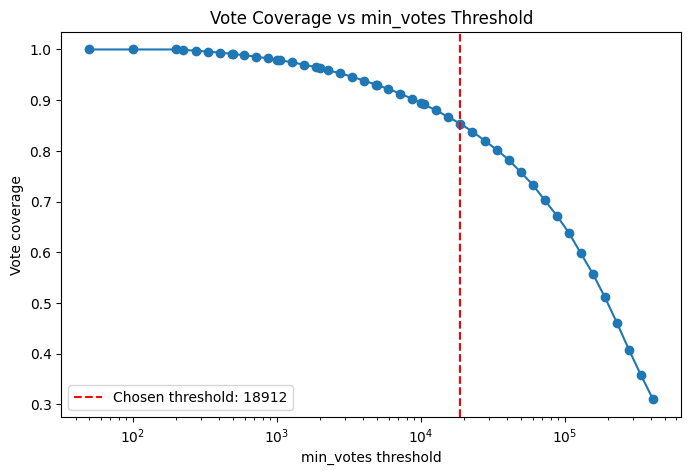

In [37]:
best, tbl = suggest_min_votes(df, mode="knee")
best, tbl.head()
# Visualize the trade-off curve
plt.figure(figsize=(8,5))
plt.plot(tbl["min_votes"], tbl["vote_coverage"], marker="o")
plt.xscale("log")
plt.xlabel("min_votes threshold")
plt.ylabel("Vote coverage")
plt.title("Vote Coverage vs min_votes Threshold")
plt.axvline(best, color="red", linestyle="--", label=f"Chosen threshold: {best}")
plt.legend()
plt.show()

In [38]:
best, tbl = suggest_min_votes(df, mode="coverage", coverage_target=0.95)
best
tbl.head()
best, tbl = suggest_min_votes(df, mode="score", w_coverage=0.7, w_size=0.3)
best
tbl.head()

,min_votes,n_movies,size_ratio,vote_coverage,score
0,50,99068,1.000000,1.000000,1.000000
1,100,99068,1.000000,1.000000,1.000000
2,200,99068,1.000000,1.000000,1.000000
3,225,94210,0.950963,0.999161,0.984702
4,273,86512,0.873259,0.997607,0.960303


In [39]:
# Export optionnel des doublons (pour inspection)
OUT_DIR = Path("data/eda")
OUT_DIR.mkdir(parents=True, exist_ok=True)

if {"primaryTitle","startYear"}.issubset(df.columns):
    dups = df[df.duplicated(["primaryTitle","startYear"], keep=False)]\
            .sort_values(["primaryTitle","startYear"])
    dups_path = OUT_DIR / "duplicates_title_year.csv"
    dups.to_csv(dups_path, index=False)
    print("Saved:", dups_path, "rows:", len(dups))
else:
    print("Skipping duplicates export (missing columns).")

Saved: data/eda/duplicates_title_year.csv rows: 609
